=== Person 1: Dataset ===
  Digit 0: 980 images
  Digit 1: 1135 images
  Digit 2: 1032 images
  Digit 3: 1010 images
  Digit 4: 982 images
  Digit 5: 892 images
  Digit 6: 958 images
  Digit 7: 1028 images
  Digit 8: 974 images
  Digit 9: 1009 images


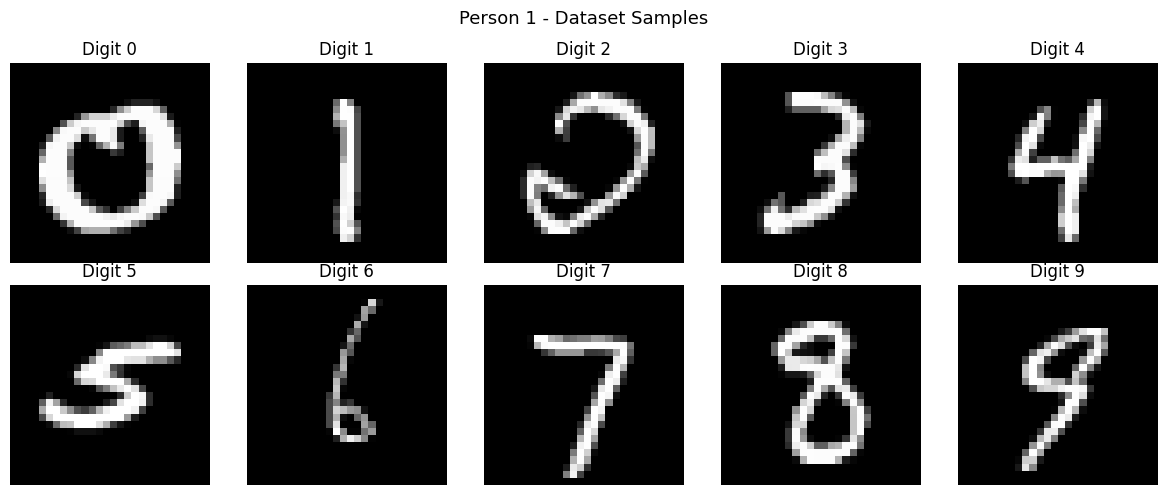


=== Person 2: Preprocessing ===
  Image shape: (28, 28)
  Pixel range: 0.00 – 1.00


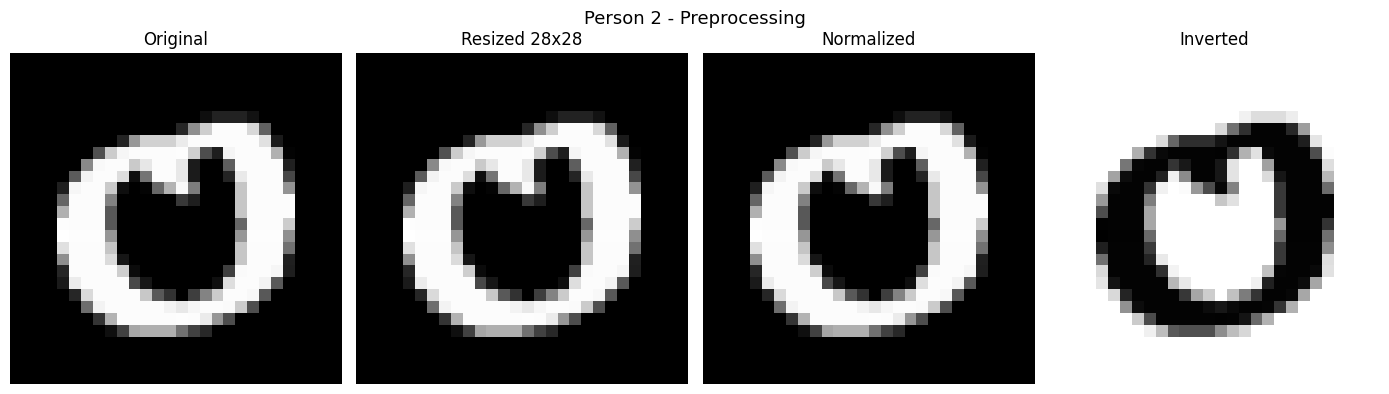


=== Person 3: Filtering ===
  Gaussian, Median, Sharpening applied ✓


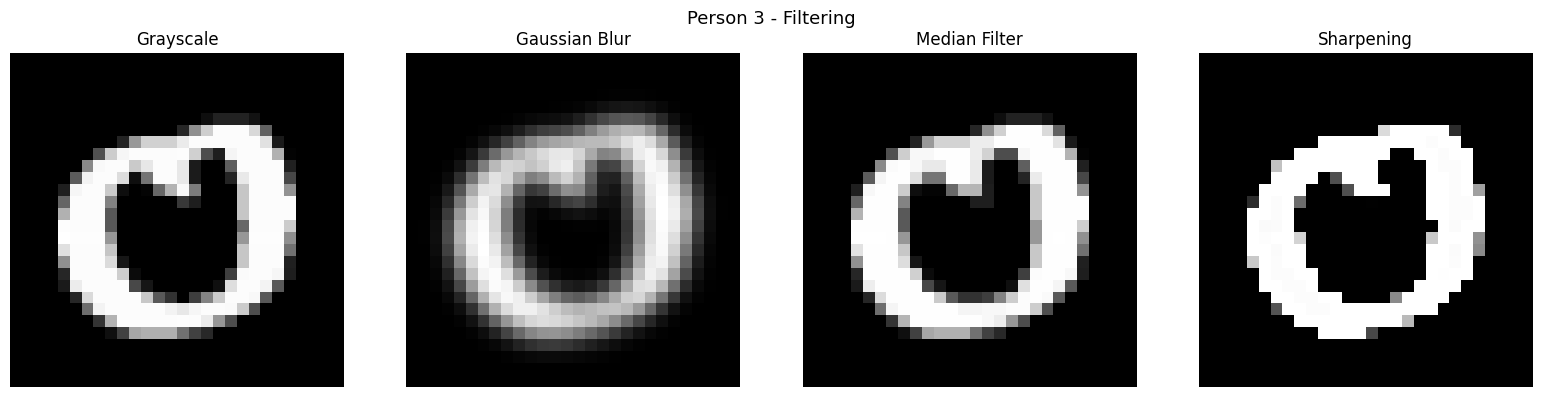


=== Person 4: Edge Detection ===
  Sobel, Canny, Otsu applied ✓


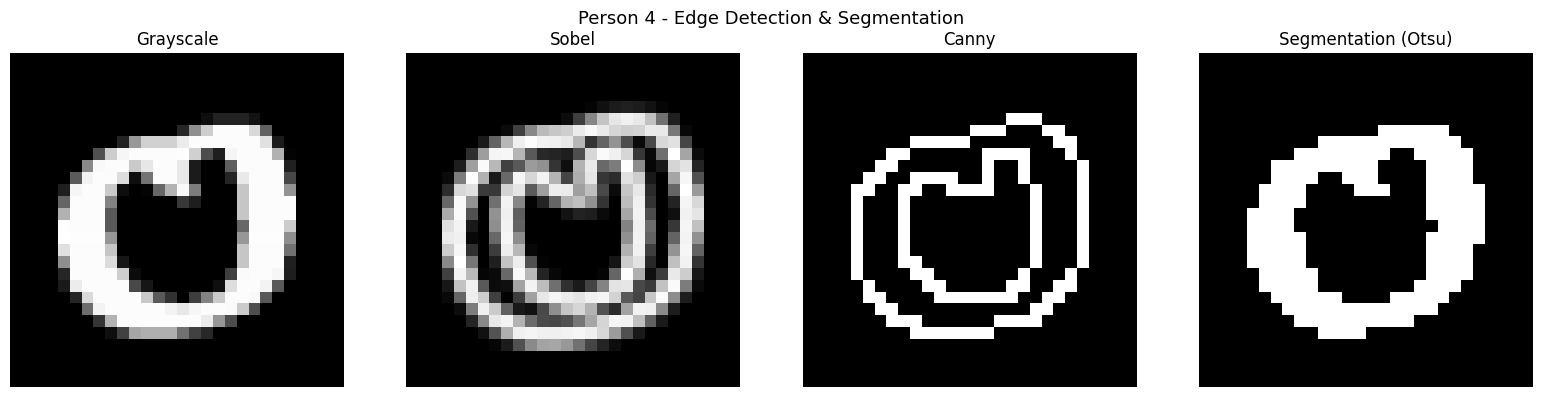


✓ Full pipeline complete!


In [2]:
# CS.383 — Image Processing Project
# Full Pipeline: Dataset → Preprocessing → Filtering → Edge Detection

import os
import zipfile
import numpy as np
from skimage import io, transform, color
from skimage.filters import gaussian, median
from skimage.morphology import disk
import cv2
import matplotlib.pyplot as plt

# ============================================================
# فك الـ zip أول
# ============================================================
zip_path = "/content/test (2).zip"
extract_path = "/content/"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

dataset_path = "/content/test"
classes = [str(i) for i in range(10)]

# ============================================================
# PERSON 1: Dataset Collection
# ============================================================
print("=== Person 1: Dataset ===")
for cls in classes:
    folder = os.path.join(dataset_path, cls)
    count = len(os.listdir(folder)) if os.path.exists(folder) else 0
    print(f"  Digit {cls}: {count} images")

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle("Person 1 - Dataset Samples", fontsize=13)
for i, cls in enumerate(classes):
    folder = os.path.join(dataset_path, cls)
    files = os.listdir(folder)
    img = io.imread(os.path.join(folder, files[0]))
    axes[i//5][i%5].imshow(img, cmap='gray')
    axes[i//5][i%5].set_title(f"Digit {cls}")
    axes[i//5][i%5].axis('off')
plt.tight_layout()
plt.show()

# ============================================================
# PERSON 2: Preprocessing
# (على أول صورة من digit 0)
# ============================================================
print("\n=== Person 2: Preprocessing ===")

sample_folder = os.path.join(dataset_path, "0")
sample_file   = os.listdir(sample_folder)[0]
image = io.imread(os.path.join(sample_folder, sample_file))

image_resized = transform.resize(image, (28, 28), anti_aliasing=True)

if image_resized.ndim == 3:
    image_gray = color.rgb2gray(image_resized)
else:
    image_gray = image_resized

image_norm = image_gray / image_gray.max()
image_inv  = 1.0 - image_norm

print(f"  Image shape: {image_resized.shape}")
print(f"  Pixel range: {image_norm.min():.2f} – {image_norm.max():.2f}")

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
fig.suptitle("Person 2 - Preprocessing", fontsize=13)
for ax, img, title in zip(axes,
    [image, image_resized, image_norm, image_inv],
    ["Original", "Resized 28x28", "Normalized", "Inverted"]):
    ax.imshow(img, cmap='gray')
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.show()

# ============================================================
# PERSON 3: Image Filtering
# ============================================================
print("\n=== Person 3: Filtering ===")

gray = (image_norm * 255).astype(np.uint8)

img_gaussian = gaussian(gray, sigma=1)
img_median   = median(gray, disk(1))
kernel       = np.array([[0,-1,0],[-1,5,-1],[0,-1,0]])
img_sharp    = cv2.filter2D(gray, -1, kernel)

print("  Gaussian, Median, Sharpening applied ✓")

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle("Person 3 - Filtering", fontsize=13)
for ax, img, title in zip(axes,
    [gray, img_gaussian, img_median, img_sharp],
    ["Grayscale", "Gaussian Blur", "Median Filter", "Sharpening"]):
    ax.imshow(img, cmap='gray')
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.show()

# ============================================================
# PERSON 4: Edge Detection & Segmentation
# ============================================================
print("\n=== Person 4: Edge Detection ===")

sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
sobel  = cv2.magnitude(sobelx, sobely).astype(int)
canny  = cv2.Canny(gray, 50, 150)
_, segmented = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

print("  Sobel, Canny, Otsu applied ✓")

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle("Person 4 - Edge Detection & Segmentation", fontsize=13)
for ax, img, title in zip(axes,
    [gray, sobel, canny, segmented],
    ["Grayscale", "Sobel", "Canny", "Segmentation (Otsu)"]):
    ax.imshow(img, cmap='gray')
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.show()

print("\n✓ Full pipeline complete!")

In [3]:
import os
for cls in range(10):
    folder = f"/content/test/{cls}"
    count = len(os.listdir(folder)) if os.path.exists(folder) else 0
    print(f"Digit {cls}: {count} images")

Digit 0: 980 images
Digit 1: 1135 images
Digit 2: 1032 images
Digit 3: 1010 images
Digit 4: 982 images
Digit 5: 892 images
Digit 6: 958 images
Digit 7: 1028 images
Digit 8: 974 images
Digit 9: 1009 images
